In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import random
import os.path as osp

from rdkit import Chem
import deepchem as dc
from deepchem.feat.smiles_tokenizer import BasicSmilesTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch_geometric.transforms as T
from torch_geometric.utils import negative_sampling, convert, to_dense_adj,structured_negative_sampling
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.nn.conv import MessagePassing

import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import ExponentialLR,MultiplicativeLR
from torch import Tensor
from torch.utils.data import DataLoader

from gensim.models import word2vec
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import pickle

from mol2vec.features import mol2alt_sentence, mol2sentence, MolSentence, DfVec
import torch
from sklearn.metrics import roc_auc_score ,auc,precision_recall_curve,f1_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning

In [14]:
DDI_graph = pd.read_csv('https://raw.githubusercontent.com/liiniix/BioSNAP/master/ChCh-Miner/ChCh-Miner_durgbank-chem-chem.tsv', sep='\t')
DDI_graph.rename(columns={'Drug1': 'src', 'Drug2': 'dst'}, inplace=True)
DrugIDs_in_graph = np.unique(DDI_graph.values) # there are 1514 unique drugs in the graph

In [15]:
len(DDI_graph['src'].unique())

1317

In [16]:
G = nx.from_pandas_edgelist(DDI_graph, 'src', 'dst')

In [17]:
#smiles

In [18]:
drugsSMILES = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/structure%20links%202.csv')
drugID_smiles = drugsSMILES[["DrugBank ID", "SMILES"]]
drugID_smiles.dropna(inplace=True)
drugID_smiles.reset_index(drop=True, inplace=True)

/tmp/ipykernel_515711/706743108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_smiles.dropna(inplace=True)


In [19]:
# Description

In [20]:
drugsDESC = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/Drug_description.csv')
drugID_DESC = drugsDESC[["Drug ID", "Discription"]]
drugID_DESC.dropna(inplace=True)
drugID_DESC.reset_index(drop=True, inplace=True)

/tmp/ipykernel_515711/1344816557.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_DESC.dropna(inplace=True)


In [21]:
#checking if a molecule has a valid molecule corespodn to the smiles string
def is_valid_molecule(smiles) -> bool:
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

In [22]:
valid_smiles = pd.DataFrame(drugID_smiles)
valid_smiles['IsValidMolecule'] = drugID_smiles['SMILES'].apply(is_valid_molecule)
df_valid_molecules = valid_smiles[valid_smiles['IsValidMolecule']]

# Drop the temporary 'IsValidMolecule' column
df_valid_molecules = df_valid_molecules.drop(columns=['IsValidMolecule'])

[09:59:20] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[09:59:20] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[09:59:20] SMILES Parse Error: check for mistakes around position 84:
[09:59:20] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[09:59:20] ~~~~~~~~~~~~~~~~~~~~^
[09:59:20] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[09:59:20] SMILES Parse Error: check for mistakes around position 40:
[09:59:20] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[09:59:20] ~~~~~~~~~~~~~~~~~~~~^
[09:59:20] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C

In [23]:

allowed_drug=[list(df_valid_molecules['DrugBank ID']),list(drugID_DESC['Drug ID'])]
# There are 1278 drugIDs that occur in the graph. Some graph nodes do not have associated SMILES or drug description

#droping the links that do not have any SMILES
for l in allowed_drug:
  for index, row in DDI_graph.iterrows():
      # Check if both cells in the row are in the allowed cells list
      if row['src'] not in l or row['dst'] not in l:
          #b If either cell is not in the allowed cells list, remove the row
          DDI_graph.drop(index, inplace=True)



In [24]:
#27800 edges
DDI_graph=DDI_graph.reset_index(drop=True)


In [25]:
#save the drugs smiles and drug description in the networks into a new dataframe
drugID_smiles_ddi = drugID_smiles[drugID_smiles['DrugBank ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_smiles_ddi=drugID_smiles_ddi.reset_index(drop=True)
drugID_DESC_ddi = drugID_DESC[drugID_DESC['Drug ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_DESC_ddi=drugID_DESC_ddi.reset_index(drop=True)

In [26]:
# graph object
# recycled code from the PyG_data function to map drugs back to node ids

DrugIDs_in_graph = np.unique(DDI_graph.values)
node_id_map = {node_name: i for i, node_name in enumerate(DrugIDs_in_graph)}
id_node_map = {i: node_name for i, node_name in enumerate(DrugIDs_in_graph)}
id_node_map

{0: 'DB00006',
 1: 'DB00007',
 2: 'DB00014',
 3: 'DB00035',
 4: 'DB00080',
 5: 'DB00091',
 6: 'DB00115',
 7: 'DB00120',
 8: 'DB00121',
 9: 'DB00122',
 10: 'DB00126',
 11: 'DB00130',
 12: 'DB00136',
 13: 'DB00140',
 14: 'DB00146',
 15: 'DB00150',
 16: 'DB00153',
 17: 'DB00158',
 18: 'DB00159',
 19: 'DB00162',
 20: 'DB00163',
 21: 'DB00165',
 22: 'DB00166',
 23: 'DB00169',
 24: 'DB00170',
 25: 'DB00173',
 26: 'DB00175',
 27: 'DB00176',
 28: 'DB00177',
 29: 'DB00178',
 30: 'DB00180',
 31: 'DB00181',
 32: 'DB00182',
 33: 'DB00184',
 34: 'DB00185',
 35: 'DB00186',
 36: 'DB00187',
 37: 'DB00188',
 38: 'DB00190',
 39: 'DB00191',
 40: 'DB00193',
 41: 'DB00195',
 42: 'DB00196',
 43: 'DB00197',
 44: 'DB00198',
 45: 'DB00199',
 46: 'DB00200',
 47: 'DB00201',
 48: 'DB00202',
 49: 'DB00203',
 50: 'DB00204',
 51: 'DB00205',
 52: 'DB00206',
 53: 'DB00207',
 54: 'DB00208',
 55: 'DB00209',
 56: 'DB00210',
 57: 'DB00211',
 58: 'DB00213',
 59: 'DB00214',
 60: 'DB00215',
 61: 'DB00216',
 62: 'DB00218',
 6

In [27]:
def PyG_data(feature,DDI_graph):
  DrugIDs_in_graph = np.unique(DDI_graph.values)
  node_id_map = {node_name: i for i, node_name in enumerate(DrugIDs_in_graph)}
  # Replace node names with integer IDs in the edge list
  src = [node_id_map[node_name] for node_name in DDI_graph['src']]
  dst = [node_id_map[node_name] for node_name in DDI_graph['dst']]
  # Stack the arrays side by side to create a 2D array
  combined_array = np.column_stack((np.array(src), np.array(dst)))
  edge_index = []  # List of tuples representing edges between drugs
  for drug_1, drug_2 in combined_array:
    # Create an undirected graph by adding edges in both directions
    edge_index.append((drug_1, drug_2))
    edge_index.append((drug_2, drug_1))
  #Replace node names with integer IDs in the feature
  feature=torch.tensor(feature,dtype=torch.float32)
  data = Data(x=feature, edge_index=torch.tensor(edge_index).t().contiguous())
  return data

In [28]:
transform = RandomLinkSplit(num_val=0.2,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=1.0)
#train_data, val_data, test_data = transform(data)

In [29]:
#### 5-2-5-Language models

In [30]:
allowed_drug=list(df_valid_molecules['DrugBank ID'])+list(drugID_DESC['Drug ID'])
def LM(DDI_graph,allowed_drug,model_name,dir,s):
    Drug=pd.read_csv(dir, sep=s,index_col=0)
    if 'Unnamed: 0' in Drug.columns:
      Drug.drop(columns='Unnamed: 0', inplace=True)
    df = Drug[Drug.iloc[:, 0].isin(allowed_drug)]
    df=df.reset_index(drop=True)
    if 'Discription' in df.columns:
      features=df.drop(df.columns[[0, 1, 2]], axis=1)
    else:
      features=df.drop(df.columns[[0, 1]], axis=1)
    print(model_name)
    return  features.values, DDI_graph

In [31]:
##6- GCN (Multi-view representation Fusion)


In [32]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
    def encode(self, x, edge_index):
        x=self.conv1(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv2(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv3(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(
            dim=-1
        )  # product of a pair of nodes on each edge

    def decode_all(self, z):
        prob_adj = z @ z.t()
        return (prob_adj > 0).nonzero(as_tuple=False).t()
    
    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

In [33]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(train_data.x, train_data.edge_index) # initializing GCN model
    out = model.decode(z, edge_label_index).view(-1)
    loss = criterion(out, edge_label)
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss


@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1).sigmoid()
    roc=roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())
    label=data.edge_label.cpu().numpy()
    score=out.cpu().numpy()
    return roc,label,score

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
Embedding_models={
                  #'GPTSMILES':LM(DDI_graph,allowed_drug,'GPT+SMILES','/data/giobbi/embeddings/SMILES_GPT.csv','\t'),
                  'GPTDesc':LM(DDI_graph,allowed_drug,'GPT+Desc','/data/giobbi/embeddings/Dr_Desc_GPT.csv','\t'),
                  
                  #'No Feature':no_feature(drugID_smiles_ddi,DDI_graph),
                  #'Morgan':Morgan(drugID_smiles_ddi,DDI_graph),
                  #'Mol2vec':Mol2Vec(drugID_smiles_ddi,DDI_graph),
                  #'SPVec':character2vec(drugID_smiles_ddi,DDI_graph),
                  #'Doc2vec':doc2vec(drugID_smiles_ddi,DDI_graph),
                  
                  #'ChemBertaSMILES':LM(DDI_graph,allowed_drug,'Chemberta+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SMILES_Chemberta.csv',','),
                  #'MolformerSMILES':LM(DDI_graph,allowed_drug,'Molformer+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SMILES_Molformer.csv',','),
                  #'SBERTSMILES':LM(DDI_graph,allowed_drug,'SBERT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SBERT/SMILES_SBert.csv',','),
                  #'AngledBERTSMILES':LM(DDI_graph,allowed_drug,'AngledBERT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/AngleBERT/SMILES_angleBert.csv',','),
                  
                  
                  #'LLaMASMILES':LM(DDI_graph,allowed_drug,'LLaMA+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/LLaMA/llama65b_base_SMILES_embeddings.csv','\t'),
                  #'LLaMA2SMILES':LM(DDI_graph,allowed_drug,'LLaMA2+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/LLaMA II/llamaII7b_base_SMILES_embeddings.csv','\t'),
                  #'AngledLLaMA2SMILES':LM(DDI_graph,allowed_drug,'AngledLLaMA+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/AngleLLaMA/SMILES_angleLlama.csv',','),
                  #'BERTDesc':LM(DDI_graph,allowed_drug,'BERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/BERT/bert50mt_base_Discription_embeddings.csv','\t'),
                  #'SBERTDesc':LM(DDI_graph,allowed_drug,'SBERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/SBERT/Desc_SBert.csv',','),
                  #'AngledBERTDesc':LM(DDI_graph,allowed_drug,'AngledBERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/AngleBERT/Drug_description_angleBERT.csv',','),
                  
                  #'LLaMADesc':LM(DDI_graph,allowed_drug,'LLaMA+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/LLaMA/llama65b_base_Discription_embeddings.csv','\t'),
                  #'LLaMA2Desc':LM(DDI_graph,allowed_drug,'LLaMA2+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/LLaMA II/llamaII7b_base_Discription_embeddings.csv','\t'),
                  #'AngledLLaMA2Desc':LM(DDI_graph,allowed_drug,'AngledLLaMA+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/AngleLLaMA/Drug_description_angleLlama.csv',','),
                  }

GPT+Desc


In [36]:
lmbda = lambda epoch: 0.96

In [37]:
LR=[#0.01,
   0.001,
    #0.0001
    #,0.0002,0.0003,0.00001
    ]


#modelname=['No Feature','Morgan','Mol2vec','SPVec','Doc2Vec',
         # 'BERTSMILES','SBERTSMILES','AngledBERTSMILES','GPTSMILES','LLaMASMILES','LLaMA2SMILES','AngledLLaMA2SMILES',
         # 'BERTDesc','SBERTDesc','AngledBERTDesc','GPTDesc','LLaMADesc','LLaMA2Desc','AngledLLaMA2Desc']


modelname=['GPT+SMILES']
AUC=pd.DataFrame(columns = [#'0.01','0.001',
                            '0.0001'
                            #,'0.0002','0.0003','0.00001'
                            ])
PR=pd.DataFrame(columns = [#'0.01','0.001',
                            '0.0001'
                            #,'0.0002','0.0003','0.00001'
                            ])


AUC['Embedding']=modelname
PR['Embedding']=modelname

for l in LR:
  print('-------------------------------')
  print('=====Learning Rate:',l,'=======')
  print('-------------------------------')
  results_AUC=[]
  results_PR=[]
  for modelname, emb in Embedding_models.items():
    print('-------------------------------')
    print('=========',modelname,'=========')
    print('-------------------------------')
    data=PyG_data(emb[0],emb[1])
    train_data, val_data, test_data = transform(data)
    model = Net(data.num_features, 256, 256).to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=l)
    scheduler = MultiplicativeLR(optimizer, lr_lambda=lmbda)
    criterion = torch.nn.BCEWithLogitsLoss()
    '''
    neg_edge_index = negative_sampling(
          edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
          num_neg_samples=train_data.edge_label_index.size(1), method='sparse')'''
    struct_neg_tup=structured_negative_sampling(edge_index=train_data.edge_index,num_nodes=train_data.num_nodes,contains_neg_self_loops = False)
    neg_edge_index = torch.stack((struct_neg_tup[0], struct_neg_tup[2]), dim=0)
    neg_edge_index, _ = torch.unique(neg_edge_index, dim=1, return_inverse=True)

    edge_label_index = torch.cat(
          [train_data.edge_label_index, neg_edge_index],
          dim=-1,
      )
    edge_label = torch.cat([
          train_data.edge_label,
          train_data.edge_label.new_zeros(neg_edge_index.size(1))
      ], dim=0)
    best_val_auc = final_test_auc = 0
    for epoch in range(1, 100):
        loss = train()
        val_auc = test(val_data)[0]
        test_auc = test(test_data)[0]
        label=test(test_data)[1]
        score=test(test_data)[2]
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            final_test_auc = test_auc
            best_scores=score
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}')

    precision, recall, thresholds = precision_recall_curve(label, best_scores)
    pr=auc(recall, precision)
    results_AUC.append({"Embedding":modelname,"AUC":final_test_auc})
    results_PR.append({"Embedding":modelname,"PR_AUC": pr})
    #del data
    #del model

  #AUC[str(l)]=results_AUC['AUC']
  #PR[str(l)]=results_PR['PR_AUC']

-------------------------------
=====Learning Rate: 0.001 =======
-------------------------------
-------------------------------
========= GPTDesc =========
-------------------------------
Epoch: 001, Loss: 0.7036, Val: 0.6204
Epoch: 002, Loss: 0.6945, Val: 0.6437
Epoch: 003, Loss: 0.6939, Val: 0.6027
Epoch: 004, Loss: 0.6935, Val: 0.6367
Epoch: 005, Loss: 0.6933, Val: 0.7439
Epoch: 006, Loss: 0.6931, Val: 0.8739
Epoch: 007, Loss: 0.6928, Val: 0.9224
Epoch: 008, Loss: 0.6925, Val: 0.9412
Epoch: 009, Loss: 0.6921, Val: 0.9622
Epoch: 010, Loss: 0.6917, Val: 0.9642
Epoch: 011, Loss: 0.6908, Val: 0.9657
Epoch: 012, Loss: 0.6896, Val: 0.9600
Epoch: 013, Loss: 0.6879, Val: 0.9619
Epoch: 014, Loss: 0.6860, Val: 0.9641
Epoch: 015, Loss: 0.6834, Val: 0.9678
Epoch: 016, Loss: 0.6798, Val: 0.9673
Epoch: 017, Loss: 0.6760, Val: 0.9598
Epoch: 018, Loss: 0.6704, Val: 0.9587
Epoch: 019, Loss: 0.6650, Val: 0.9536
Epoch: 020, Loss: 0.6569, Val: 0.9552
Epoch: 021, Loss: 0.6487, Val: 0.9524
Epoch: 022, 

In [41]:
# Example: Get predictions for the first 10 test edges
edge_indices = test_data.edge_label_index[:, :10]  # shape: [2, N]
model.eval()
with torch.no_grad():
    preds = model(test_data.x, test_data.edge_index, edge_indices)
print("Predicted scores:", preds)

Predicted scores: tensor([2.1305, 1.1530, 1.6129, 1.4184, 1.0995, 1.8302, 0.8313, 2.1278, 2.0132,
        0.8366])


In [50]:
def ids_to_drug_names(edge_index_tensor):
    # edge_index_tensor: shape [2, N]
    src_names = [id_node_map[idx.item()] for idx in edge_index_tensor[0]]
    dst_names = [id_node_map[idx.item()] for idx in edge_index_tensor[1]]
    return list(zip(src_names, dst_names))

# Usage:
edge_names = ids_to_drug_names(test_data.edge_index)
print(edge_names[:5])  # Print first 5 edge name pairs

[('DB00358', 'DB00371'), ('DB00270', 'DB01392'), ('DB00598', 'DB01614'), ('DB05271', 'DB08883'), ('DB01171', 'DB01614')]


In [51]:
labels = test_data.edge_label[:10]
print("True labels:", labels)
print("Predicted scores:", preds)

True labels: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Predicted scores: tensor([2.1305, 1.1530, 1.6129, 1.4184, 1.0995, 1.8302, 0.8313, 2.1278, 2.0132,
        0.8366])


# Analyze Drug Description

In [52]:
drugsDESC_masked = drugsDESC.copy()
drug_list = drugsDESC_masked['Drug Name'].to_list()
drug_ID_list = drugsDESC_masked['Drug ID'].to_list()
drugsDESC_masked

,Drug ID,Drug Name,Discription
0,DB00001,Lepirudin,Lepirudin is a recombinant hirudin formed by 6...
1,DB00002,Cetuximab,Cetuximab is a recombinant chimeric human/mous...
2,DB00003,Dornase alfa,Dornase alfa is a biosynthetic form of human d...
3,DB00004,Denileukin diftitox,A recombinant DNA-derived cytotoxic protein co...
4,DB00005,Etanercept,Dimeric fusion protein consisting of the extra...
...,...,...,...
15230,DB17382,AUM-601,AUM-601 is a highly selective pan-TRK(tropomyo...
15231,DB17383,FN-1501,;;;;
15232,DB17384,Tinengotinib,;;;;
15233,DB17385,Lipotecan,;;;;


In [53]:
from flashtext import KeywordProcessor

# Build processor
kp = KeywordProcessor(case_sensitive=False)
for drug in drug_list:
    kp.add_keyword(drug, "<DRUG>")
for drug_ID in drug_ID_list:
    kp.add_keyword(drug_ID, "<DRUG>")



# Replace & count
drugsDESC_masked['Description_Masked'] = drugsDESC_masked['Discription'].apply(kp.replace_keywords)
drugsDESC_masked['drug_count'] = drugsDESC_masked['Discription'].apply(
    lambda x: len(kp.extract_keywords(x))
)



In [54]:
drugsDESC_masked.sort_values(by='drug_count', ascending=False, inplace=True)
drugsDESC_masked.to_csv('drug_description_masked_and_unmasked.csv')

In [55]:
drugsDESC_masked['Description_Masked'].to_csv('drug_description_masked.csv')

In [56]:
drugsDESC_masked['Discription'].to_csv('drug_description_unmasked.csv')

In [57]:
# pharma_class column

# Define keyword lists for each class
keyword_classes = {
    0: [  # Antidepressants
        "antidepressant", "tricyclic", "tca", "ssri", "snri", "maoi", "serotonin", "norepinephrine reuptake"
    ],
    1: [  # Antifungals
        "antifungal", "azole", "ergosterol", "ketoconazole", "fluconazole", "itraconazole", "voriconazole"
    ],
    2: [  # Antihypertensives
        "antihypertensive", "hypertension", "angiotensin ii receptor blocker", "arb",
        "ace inhibitor", "calcium channel blocker", "ccb", "beta-blocker"
    ],
    3: [  # Antibiotics
        "antibiotic", "macrolide", "penicillin", "cephalosporin", "fluoroquinolone", "tetracycline", "bacterial infections"
    ],
    4: [  # Antivirals
        "antiviral", "protease inhibitor", "reverse transcriptase inhibitor", "integrase inhibitor",
        "hiv", "hepatitis", "influenza"
    ],
    5: [  # Anticancer (chemotherapy / oncology)
        "antineoplastic", "chemotherapy", "kinase inhibitor", "monoclonal antibody", "cytotoxic"
    ],
    6: [  # Analgesics / Pain management
        "analgesic", "opioid", "nsaid", "pain"
    ],
    7: [  # Antidiabetics
        "antidiabetic", "insulin", "glp-1", "sglt2 inhibitor", "metformin"
    ],
    8: [  # Gastrointestinal / Acid-related
        "proton pump inhibitor", "ppi", "h2 receptor antagonist", "gerd", "ulcer"
    ]
}

import re

def assign_class(description):
    if pd.isnull(description):
        return 9  # None of the keywords
    desc = description.lower()
    for class_idx, keywords in keyword_classes.items():
        for kw in keywords:
            # For "azole" match as word ending, otherwise substring
            if kw == "azole":
                if re.search(r"\w+azole\b", desc):
                    return class_idx
            elif kw in desc:
                return class_idx
    return 9  # None of the keywords

# Assign class integer to each row
drugsDESC_masked['pharma_class'] = drugsDESC_masked['Discription'].apply(assign_class)

# Optional: check class distribution
print(drugsDESC_masked['pharma_class'].value_counts())

pharma_class
9    12770
4      541
2      493
5      403
6      319
3      249
0      160
1      141
8       81
7       78
Name: count, dtype: int64


# Visualize Embedding

In [63]:
# Load embeddings (assuming first column is DrugBank ID)
embeddings_df = pd.read_csv('/data/giobbi/embeddings/Dr_Desc_GPT.csv', sep='\t', index_col=0)
if 'Unnamed: 0' in embeddings_df.columns:
    embeddings_df = embeddings_df.drop(columns='Unnamed: 0')

# Filter to drugs in your graph (optional, if not already done)
embeddings_df = embeddings_df[embeddings_df.iloc[:, 0].isin(DrugIDs_in_graph)].reset_index(drop=True)

# Prepare drug description DataFrame (already loaded as drugsDESC)
# Make sure column names match for merging
drugsDESC_renamed = drugsDESC_masked.rename(columns={'Drug ID': 'DrugBank ID'})

# Merge on DrugBank ID
merged_df = pd.merge(embeddings_df, drugsDESC_renamed, on='DrugBank ID', how='inner')

# Now merged_df contains both embeddings and descriptions for each drug
print(merged_df.head())

KeyError: 'DrugBank ID'

In [153]:
merged_df[[ 'DrugBank ID', 'SMILES','Discription', 'Drug Name', 'Discription',	'Description_Masked',	'drug_count']].sort_values(by='drug_count', ascending=False).to_csv('merged_embeddings_and_descriptions.csv')

In [154]:
merged_df[merged_df['Discription'] == ';;;;']

,DrugBank ID,SMILES,0,1,2,3,4,5,6,7,...,1531,1532,1533,1534,1535,Drug Name,Discription,Description_Masked,drug_count,pharma_class
994,DB03880,[H][C@@](CC1=CC=CC=C1)(NC(=O)[C@]([H])(CC(C)C)...,-0.004176,0.003530,-0.008580,-0.010953,0.001073,0.017238,0.007961,-0.021698,...,0.013718,0.012009,-0.008437,0.008398,-0.010197,Batimastat,;;;;,;;;;,0,9
1087,DB06527,NCCCS(O)(=O)=O,0.003425,-0.012475,-0.002294,-0.029100,-0.009483,0.009337,0.007036,-0.016665,...,0.015268,-0.000488,0.005739,0.007082,-0.029047,Tramiprosate,;;;;,;;;;,0,9
1097,DB06659,[Cl-].[Sn+4].CCOC(=O)C1=CC2=C3[N-]\C(=C/C4=N/C...,-0.011969,-0.005788,0.001946,-0.022849,0.008919,0.017668,-0.008585,-0.029014,...,0.015924,0.006814,0.005155,0.017957,-0.022863,Rostaporfin,;;;;,;;;;,0,9
1221,DB09064,CC(C)(OC1=CC=C(C=C1)C1CC1(Cl)Cl)C(O)=O,0.002056,-0.020133,-0.017933,-0.018785,-0.002901,0.021863,0.010531,-0.000043,...,0.004804,0.011147,0.005834,-0.010524,-0.026581,Ciprofibrate,;;;;,;;;;,0,9
1321,DB00873,[H][C@@]12CC[C@](O)(C(=O)OCCl)[C@@]1(C)C[C@H](...,-0.004599,0.001263,-0.026799,-0.025185,0.001949,0.009467,-0.001476,-0.013976,...,0.019561,0.005166,-0.003236,0.011882,-0.020432,Loteprednol,;;;;,;;;;,0,9


In [155]:
merged_df['Discription'].str.contains('interact', case=False, na=False).sum()

21

In [156]:
drug_embeddings = merged_df.drop(columns=['DrugBank ID', 'SMILES', 'Discription', 'Drug Name', 'Description_Masked', 'drug_count', 'pharma_class'])

# Apply t-SNE for Dimensionality Reduction
Use sklearn.manifold.TSNE to reduce the embeddings to 2D or 3D.

In [157]:
from sklearn.manifold import TSNE

In [158]:
# shuffle for visualization purposes
drug_embeddings = drug_embeddings.sample(frac=1, random_state=42).reset_index(drop=True)

In [159]:
# Apply t-SNE for Dimensionality Reduction

# Initialize t-SNE with 2 components for 2D visualization
tsne = TSNE(n_components=2, random_state=42)

# Apply t-SNE to the drug embeddings
reduced_embeddings = tsne.fit_transform(drug_embeddings)

# Convert the reduced embeddings to a DataFrame for easier handling
reduced_embeddings_df = pd.DataFrame(reduced_embeddings, columns=['TSNE-1', 'TSNE-2'])


# Visualize t-SNE Results with Matplotlib
Plot the 2D t-SNE results using matplotlib's scatter plot.

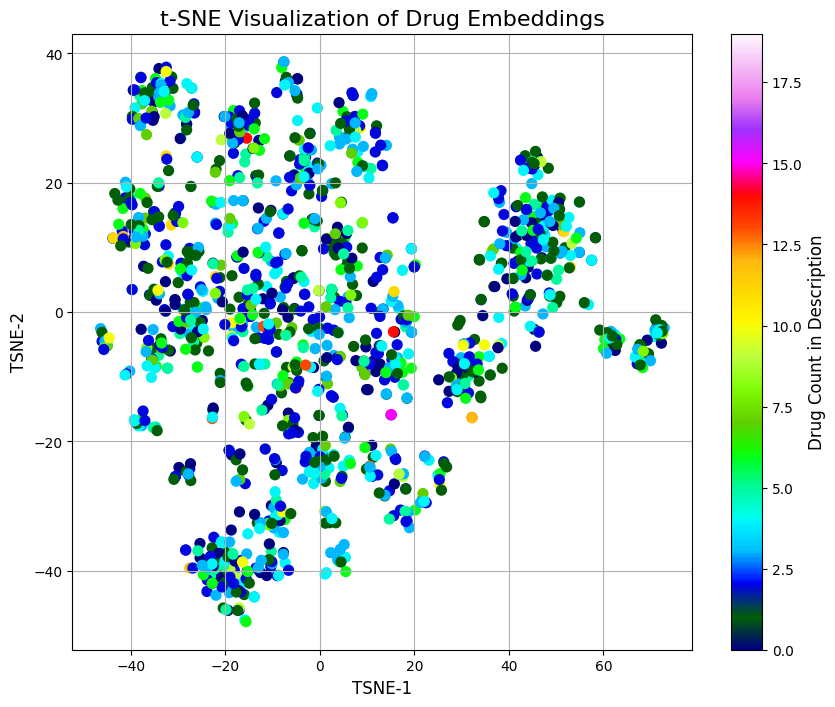

In [160]:
# Normalize the drug count for coloring
norm = plt.Normalize(merged_df['drug_count'].min(), merged_df['drug_count'].max())

color = merged_df['drug_count']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    alpha=1, s=50,
    c=color,  # Pass the raw values here
    cmap='gist_ncar',
    norm=norm
)
plt.title('t-SNE Visualization of Drug Embeddings', fontsize=16)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.grid(True)

# Add a colorbar to show the drug_count scale
cbar = plt.colorbar(scatter)
cbar.set_label('Drug Count in Description', fontsize=12)

plt.show()

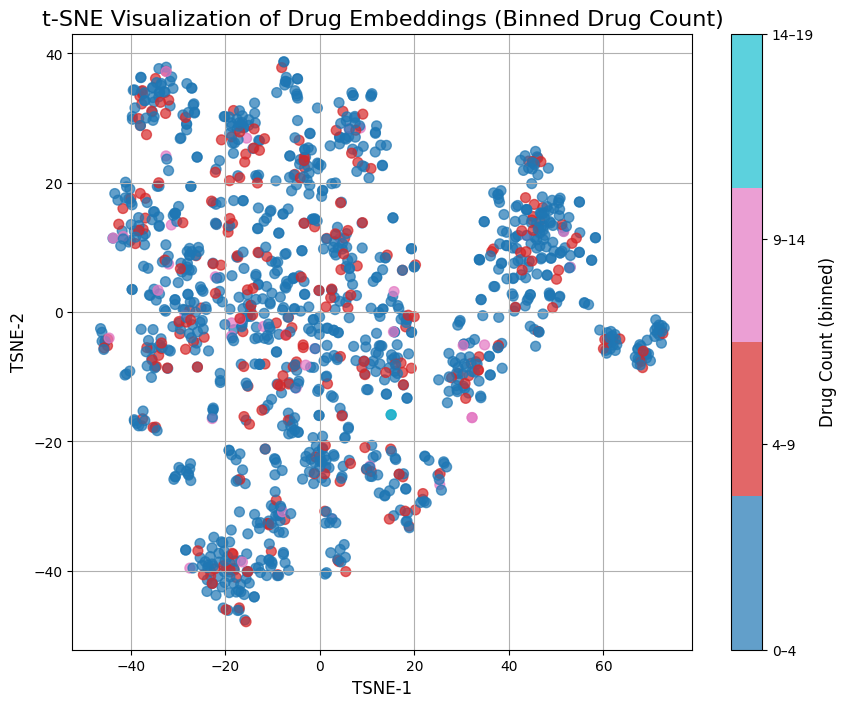

In [161]:
import matplotlib.pyplot as plt

# Bin the drug_count into N discrete bins
N_BINS =  4 # Choose the number of bins you want
bin_ = pd.cut(merged_df['drug_count'], bins=N_BINS, labels=False)

# Choose a discrete colormap
cmap = plt.get_cmap('tab10', N_BINS)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    alpha=0.7, s=50,
    c=bin_,
    cmap=cmap
)
plt.title('t-SNE Visualization of Drug Embeddings (Binned Drug Count)', fontsize=16)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.grid(True)

# Add a colorbar with bin edges as ticks
cbar = plt.colorbar(scatter, ticks=range(N_BINS))
bin_edges = pd.cut(merged_df['drug_count'], bins=N_BINS).unique().categories
cbar.ax.set_yticklabels([f'{int(interval.left)}–{int(interval.right)}' for interval in bin_edges])
cbar.set_label('Drug Count (binned)', fontsize=12)

plt.show()

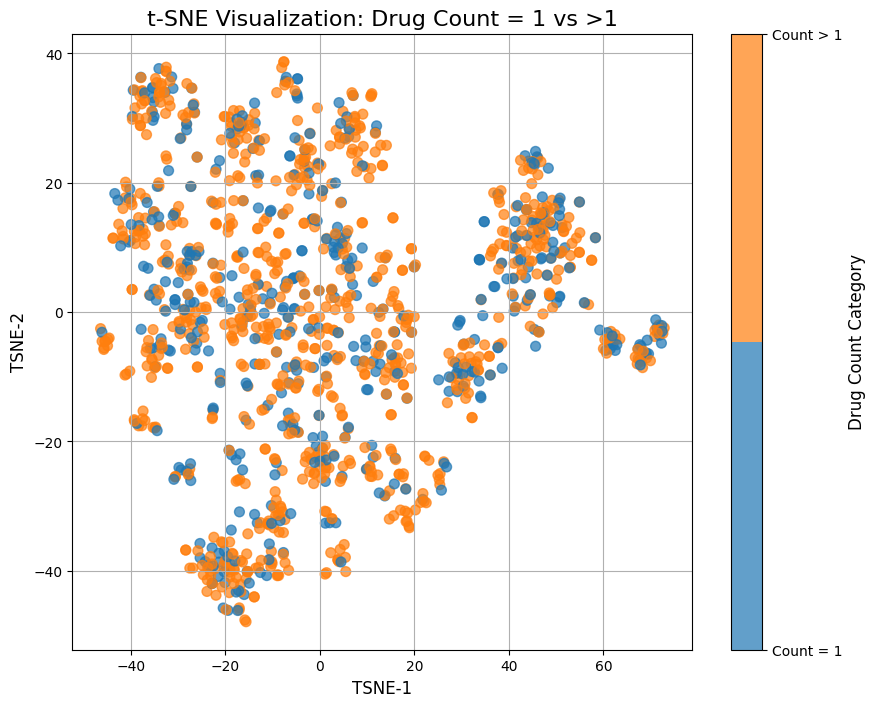

In [162]:
# ...existing code...

import matplotlib.pyplot as plt

# Create a binary column: 0 if drug_count == 1, 1 if drug_count > 1
bin_ = (merged_df['drug_count'] > 1).astype(int)

# Define a custom color map: e.g., blue for count=1, orange for count>1
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#1f77b4', '#ff7f0e'])  # blue, orange

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    alpha=0.7, s=50,
    c=bin_,
    cmap=cmap
)
plt.title('t-SNE Visualization: Drug Count = 1 vs >1', fontsize=16)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.grid(True)

# Add a colorbar with custom ticks and labels
cbar = plt.colorbar(scatter, ticks=[0, 1])
cbar.ax.set_yticklabels(['Count = 1', 'Count > 1'])
cbar.set_label('Drug Count Category', fontsize=12)

plt.show()

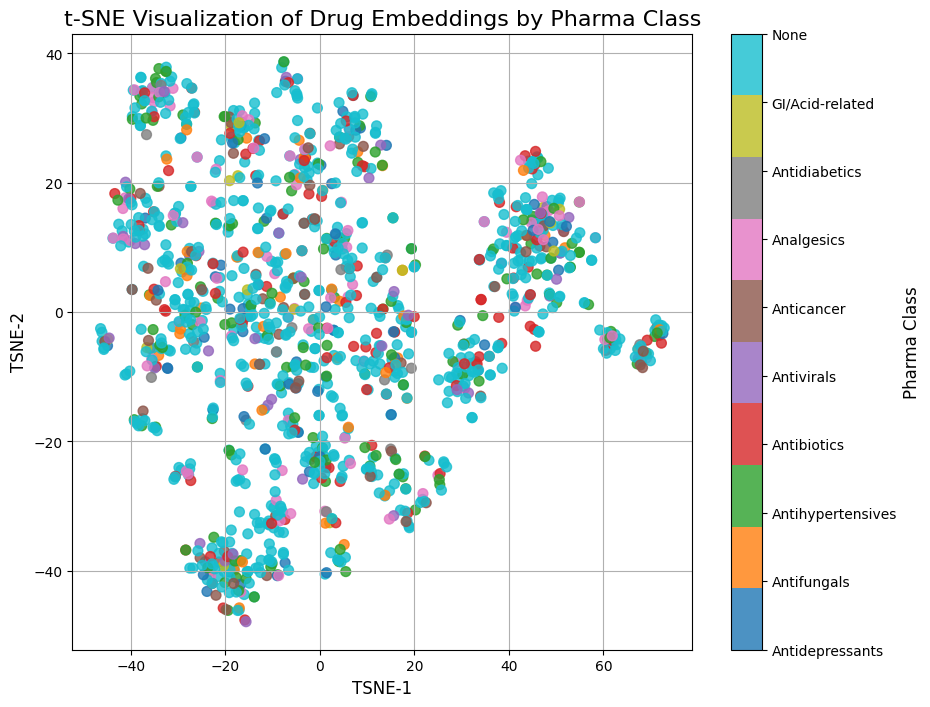

In [163]:
# Define a discrete colormap with 10 colors (9 classes + 1 "none")
from matplotlib.colors import ListedColormap
cmap = ListedColormap(plt.get_cmap('tab10').colors[:10])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    alpha=0.8, s=50,
    c=merged_df['pharma_class'],
    cmap=cmap
)
plt.title('t-SNE Visualization of Drug Embeddings by Pharma Class', fontsize=16)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.grid(True)

# Add a colorbar with class labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels([
    'Antidepressants', 'Antifungals', 'Antihypertensives', 'Antibiotics', 'Antivirals',
    'Anticancer', 'Analgesics', 'Antidiabetics', 'GI/Acid-related', 'None'
])
cbar.set_label('Pharma Class', fontsize=12)

plt.show()

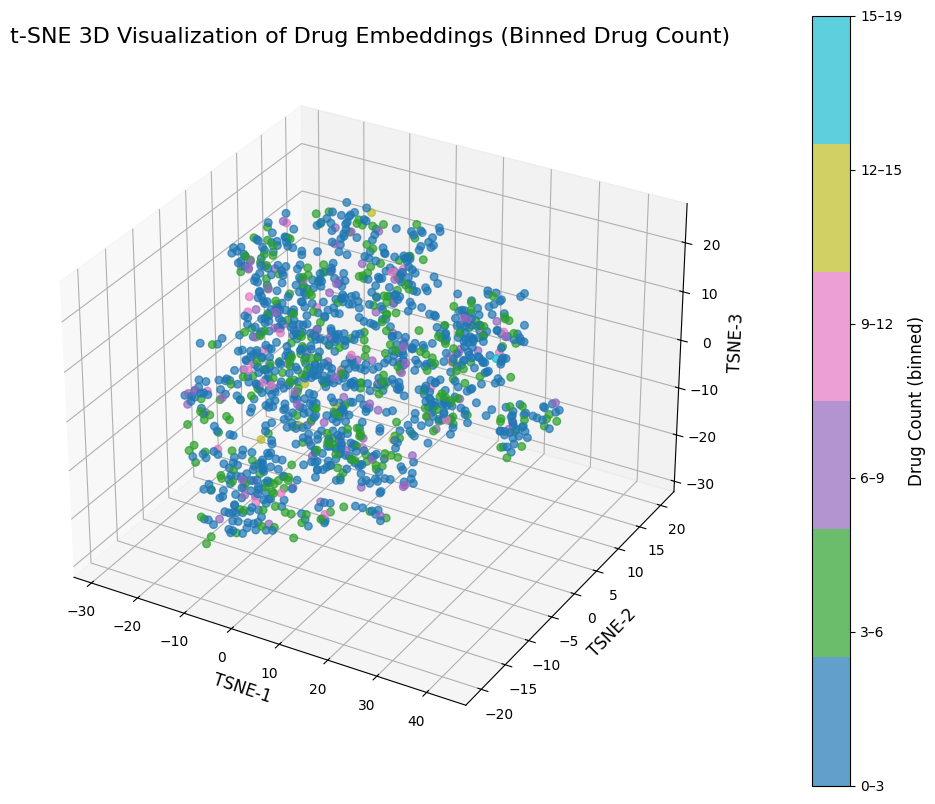

In [164]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Apply t-SNE for 3D Dimensionality Reduction
tsne = TSNE(n_components=3, random_state=42)
reduced_embeddings = tsne.fit_transform(drug_embeddings)
reduced_embeddings_df = pd.DataFrame(reduced_embeddings, columns=['TSNE-1', 'TSNE-2', 'TSNE-3'])

# Bin the drug_count into N discrete bins
N_BINS = 6  # Choose the number of bins you want
bin_ = pd.cut(merged_df['drug_count'], bins=N_BINS, labels=False)

# Choose a discrete colormap
cmap = plt.get_cmap('tab10', N_BINS)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    reduced_embeddings_df['TSNE-3'],
    c=bin_,
    cmap=cmap,
    s=30,
    alpha=0.7
)
ax.set_title('t-SNE 3D Visualization of Drug Embeddings (Binned Drug Count)', fontsize=16)
ax.set_xlabel('TSNE-1', fontsize=12)
ax.set_ylabel('TSNE-2', fontsize=12)
ax.set_zlabel('TSNE-3', fontsize=12)

# Add a colorbar with bin edges as ticks
cbar = fig.colorbar(scatter, ticks=range(N_BINS), pad=0.1)
bin_edges = pd.cut(merged_df['drug_count'], bins=N_BINS).unique().categories
cbar.ax.set_yticklabels([f'{int(interval.left)}–{int(interval.right)}' for interval in bin_edges])
cbar.set_label('Drug Count (binned)', fontsize=12)

plt.show()

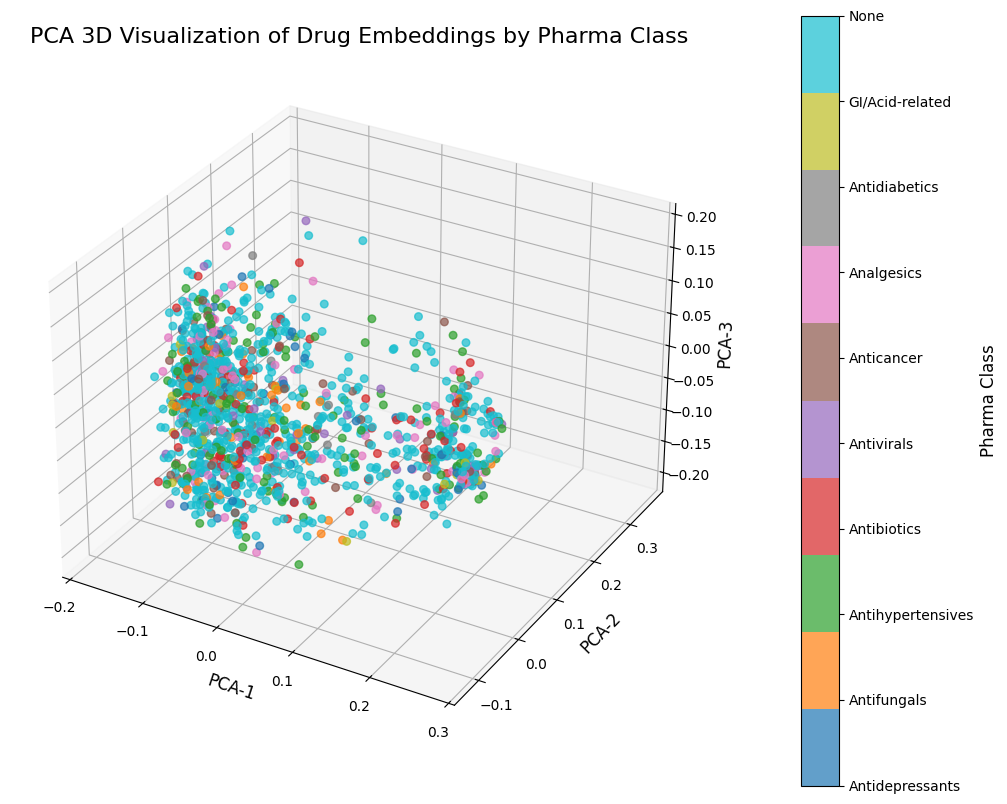

In [165]:
from sklearn.decomposition import PCA

# Apply PCA for 3D Dimensionality Reduction
pca = PCA(n_components=3)
reduced_embeddings = pca.fit_transform(drug_embeddings)
reduced_embeddings_df = pd.DataFrame(reduced_embeddings, columns=['PCA-1', 'PCA-2', 'PCA-3'])

# Define a discrete colormap with 10 colors (9 classes + 1 "none")
from matplotlib.colors import ListedColormap
cmap = ListedColormap(plt.get_cmap('tab10').colors[:10])

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    reduced_embeddings_df['PCA-1'],
    reduced_embeddings_df['PCA-2'],
    reduced_embeddings_df['PCA-3'],
    c=merged_df['pharma_class'],
    cmap=cmap,
    s=30,
    alpha=0.7
)
ax.set_title('PCA 3D Visualization of Drug Embeddings by Pharma Class', fontsize=16)
ax.set_xlabel('PCA-1', fontsize=12)
ax.set_ylabel('PCA-2', fontsize=12)
ax.set_zlabel('PCA-3', fontsize=12)

# Add a colorbar with class labels
cbar = fig.colorbar(scatter, ticks=range(10), pad=0.1)
cbar.ax.set_yticklabels([
    'Antidepressants', 'Antifungals', 'Antihypertensives', 'Antibiotics', 'Antivirals',
    'Anticancer', 'Analgesics', 'Antidiabetics', 'GI/Acid-related', 'None'
])
cbar.set_label('Pharma Class', fontsize=12)

plt.show()

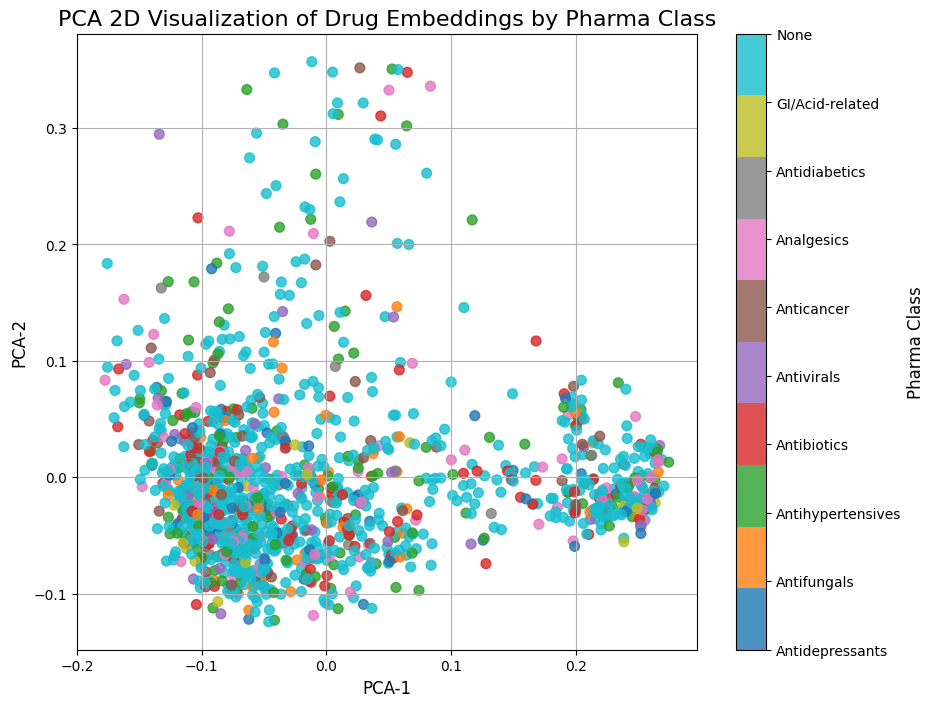

In [167]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA for 2D Dimensionality Reduction
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(drug_embeddings)
reduced_embeddings_df = pd.DataFrame(reduced_embeddings, columns=['PCA-1', 'PCA-2'])

# Define a discrete colormap with 10 colors (9 classes + 1 "none")
from matplotlib.colors import ListedColormap
cmap = ListedColormap(plt.get_cmap('tab10').colors[:10])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['PCA-1'],
    reduced_embeddings_df['PCA-2'],
    alpha=0.8, s=50,
    c=merged_df['pharma_class'],
    cmap=cmap
)
plt.title('PCA 2D Visualization of Drug Embeddings by Pharma Class', fontsize=16)
plt.xlabel('PCA-1', fontsize=12)
plt.ylabel('PCA-2', fontsize=12)
plt.grid(True)

# Add a colorbar with class labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels([
    'Antidepressants', 'Antifungals', 'Antihypertensives', 'Antibiotics', 'Antivirals',
    'Anticancer', 'Analgesics', 'Antidiabetics', 'GI/Acid-related', 'None'
])
cbar.set_label('Pharma Class', fontsize=12)

plt.show()